# Photo-z: confronto tra modelli per una stima accurata 

## Importazione delle librerie, caricamento dataset, rimozione colonna index

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score, KFold


In [2]:
df_train_noCS = pd.read_csv("data/train_noCS.csv")
if 'index' in df_train_noCS.columns:
    df_train_noCS = df_train_noCS.drop(['index'], axis=1)
    
df_test_noCS = pd.read_csv("data/test_noCS.csv")
if 'index' in df_test_noCS.columns:
    df_test_noCS = df_test_noCS.drop(['index'], axis=1)

df_train_weakCS = pd.read_csv("data/train_weakCS.csv")
if 'index' in df_train_weakCS.columns:
    df_train_weakCS = df_train_weakCS.drop(['index'], axis=1)

df_test_weakCS = pd.read_csv("data/test_weakCS.csv")
if 'index' in df_test_weakCS.columns:
    df_test_weakCS = df_test_weakCS.drop(['index'], axis=1)

df_train_mildCS = pd.read_csv("data/train_mildCS.csv")
if 'index' in df_train_mildCS.columns:
    df_train_mildCS = df_train_mildCS.drop(['index'], axis=1)

df_test_mildCS = pd.read_csv("data/test_mildCS.csv")
if 'index' in df_test_mildCS.columns:
    df_test_mildCS = df_test_mildCS.drop(['index'], axis=1)

df_train_strongCS = pd.read_csv("data/train_strongCS.csv")
if 'index' in df_train_strongCS.columns:
    df_train_strongCS = df_train_strongCS.drop(['index'], axis=1)

df_test_strongCS = pd.read_csv("data/test_strongCS.csv")
if 'index' in df_test_strongCS.columns:
    df_test_strongCS = df_test_strongCS.drop(['index'], axis=1)

In [3]:
dfs_train = {"df_train_noCS":df_train_noCS,
             "df_train_weakCS":df_train_weakCS,
             "df_train_mildCS":df_train_mildCS,
             "df_train_strongCS":df_train_strongCS}

dfs_test = {"df_test_noCS":df_test_noCS,
            "df_test_weakCS":df_test_weakCS,
            "df_test_mildCS":df_test_mildCS,
            "df_test_strongCS":df_test_strongCS}


## Exploratory Data Analysis

Intando capiamo il significato visuale della CS nei datasets. Si può notare come più è elevata la CS, e più le distribuzioni di train e test delle varie features siano diverse. Vediamolo graficamente:

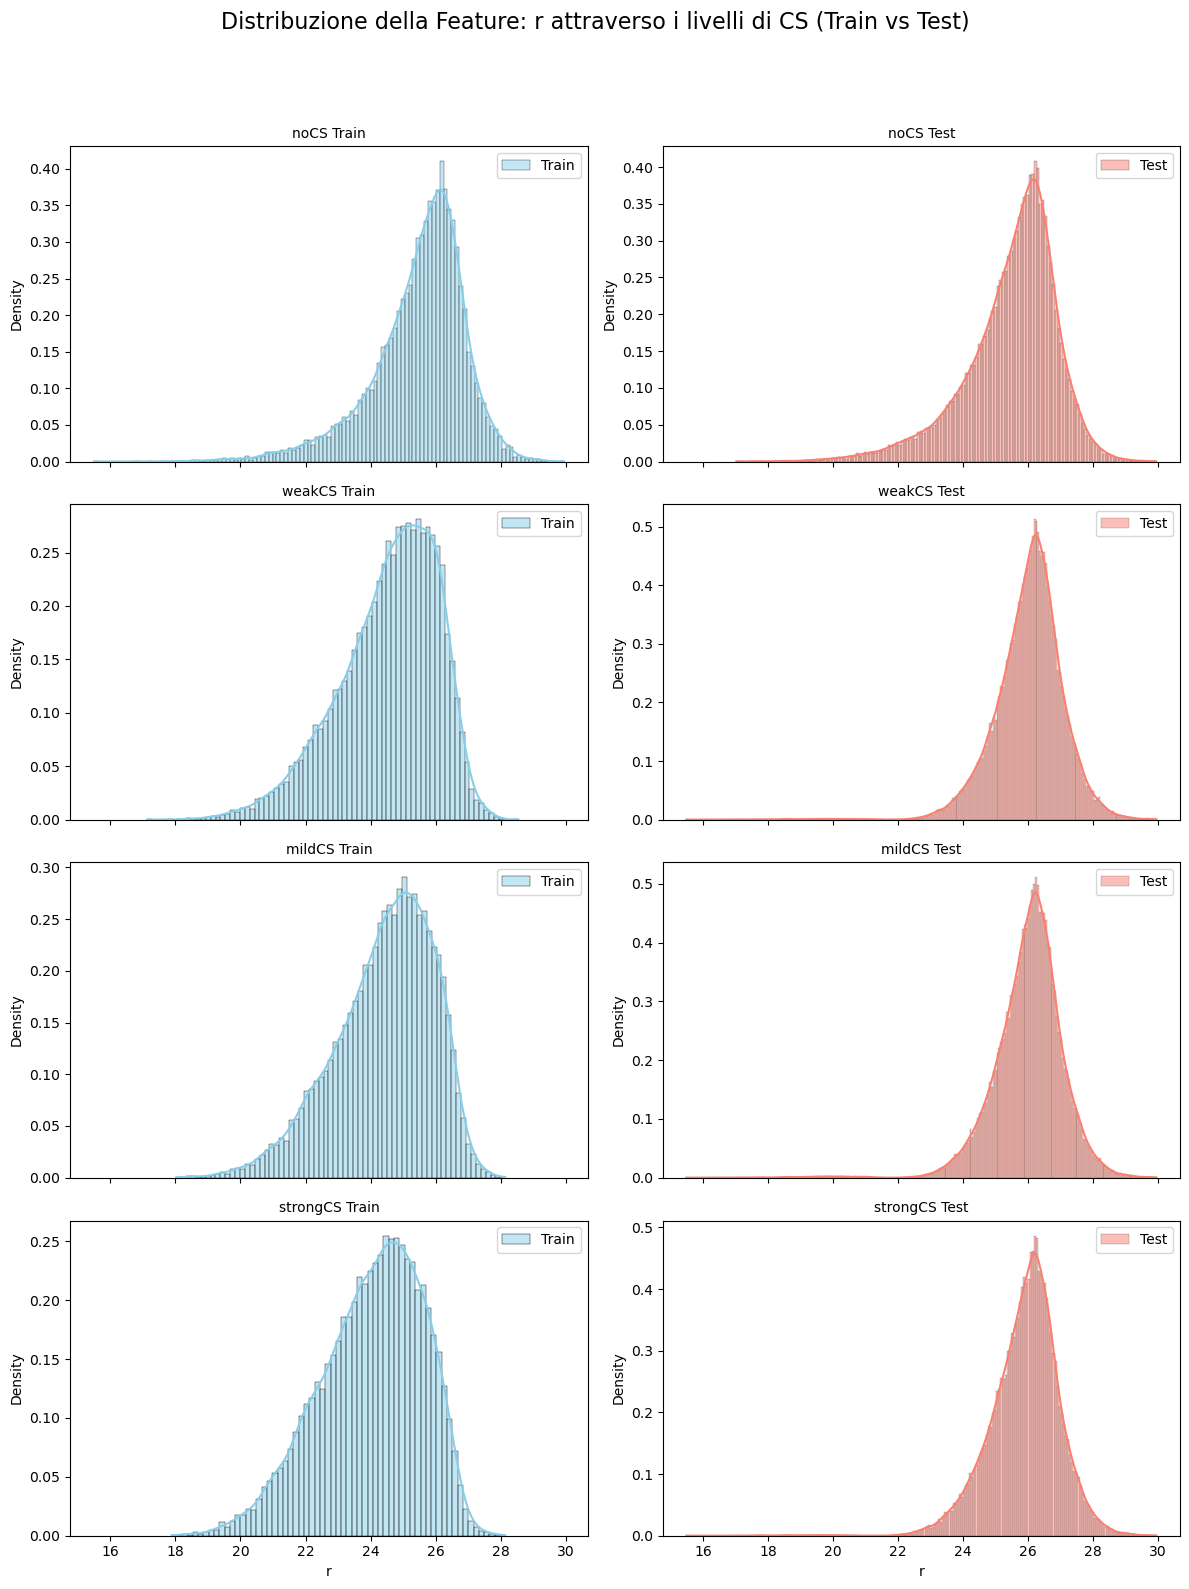

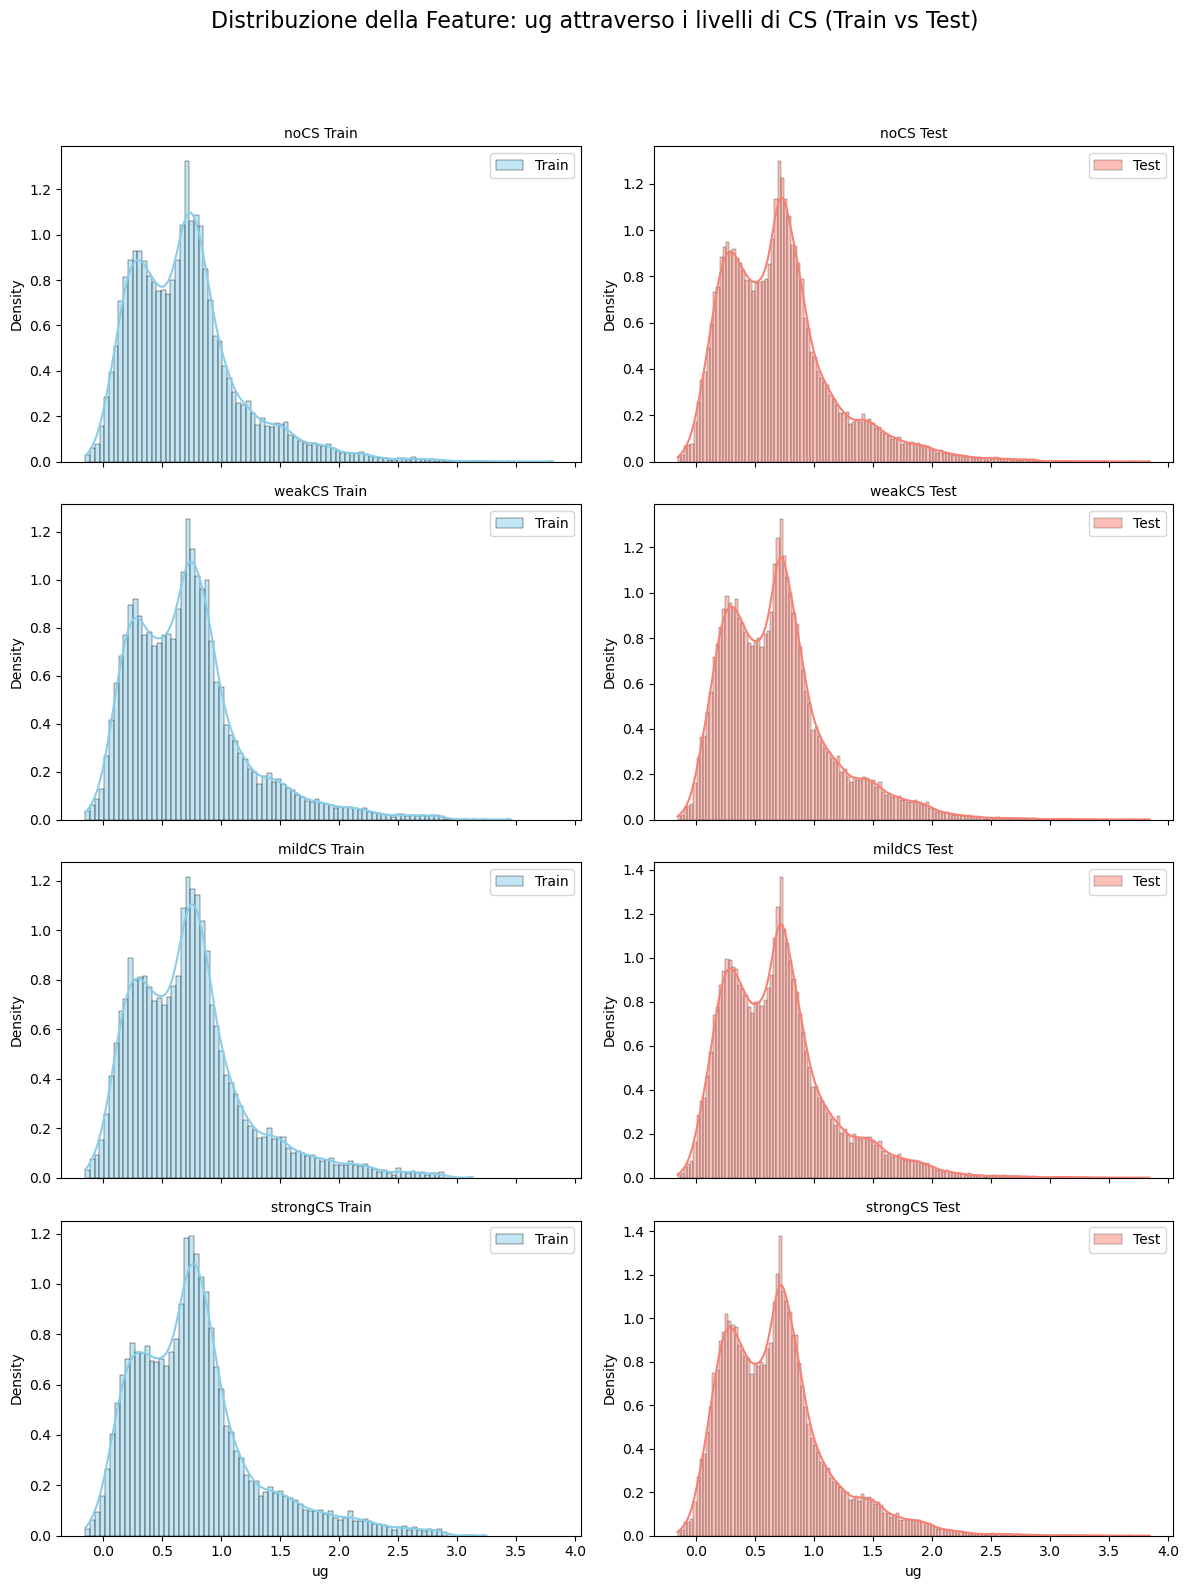

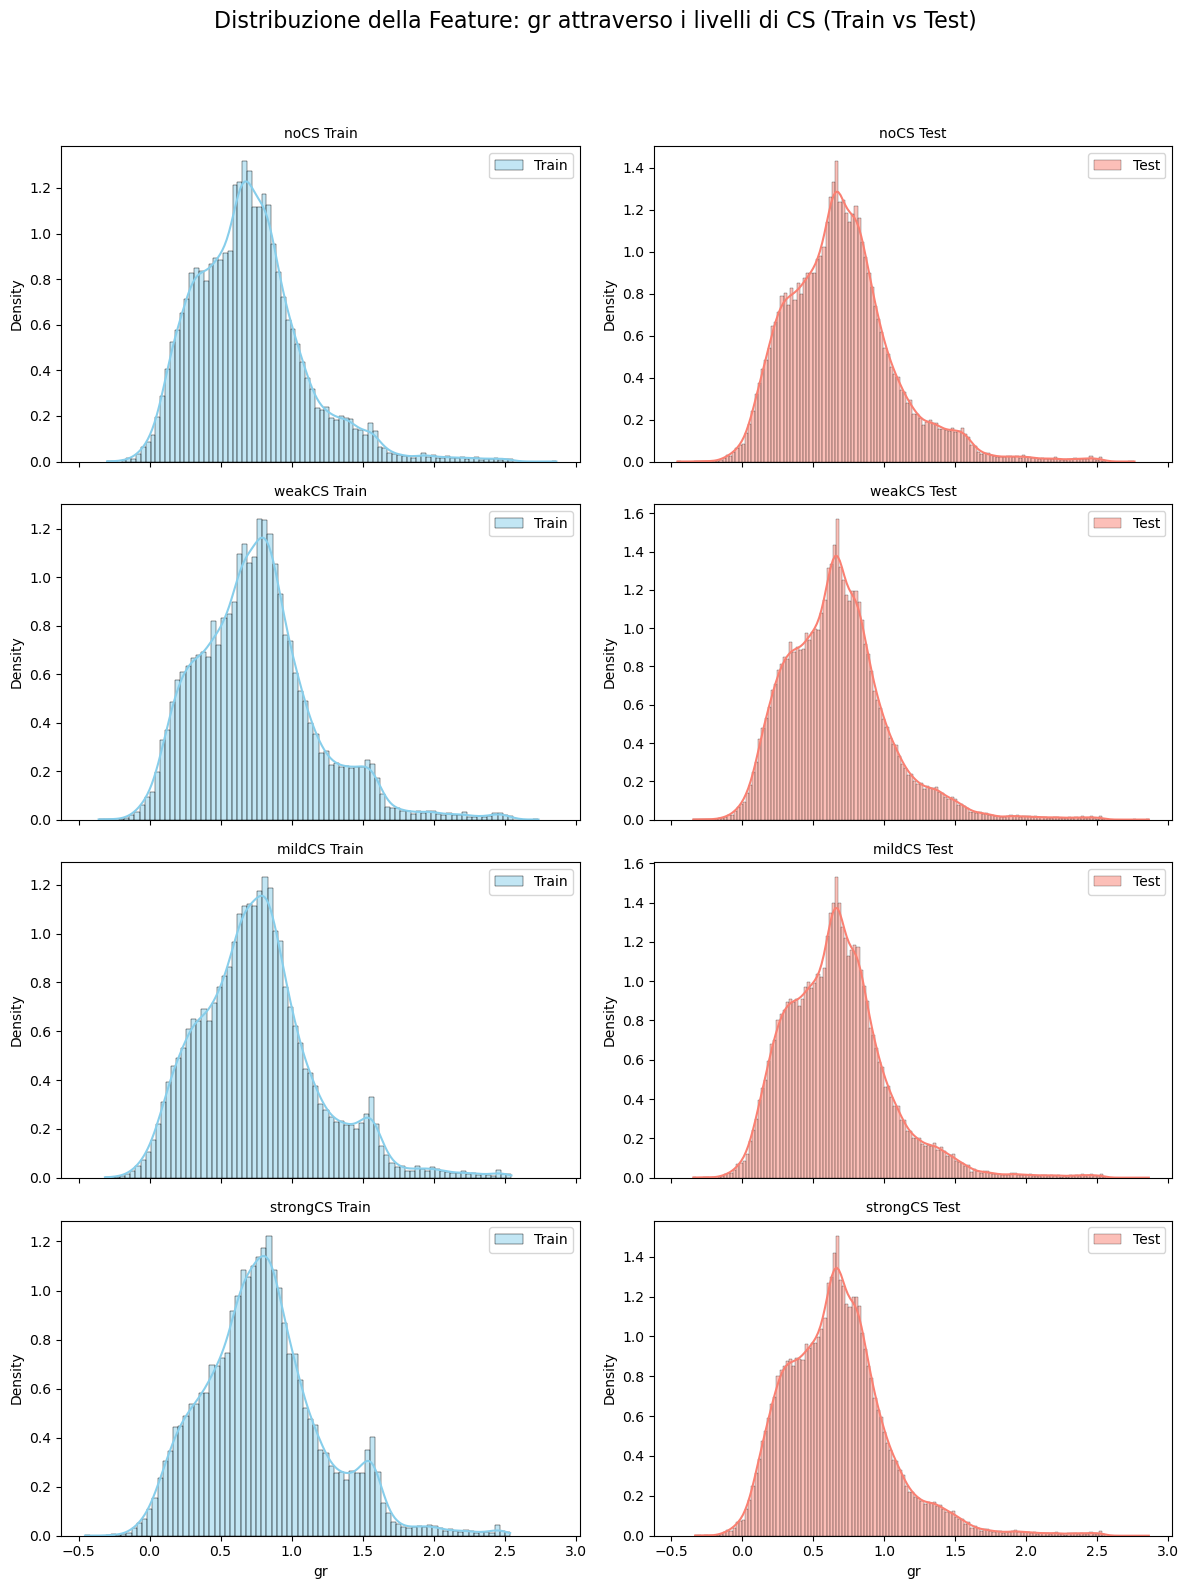

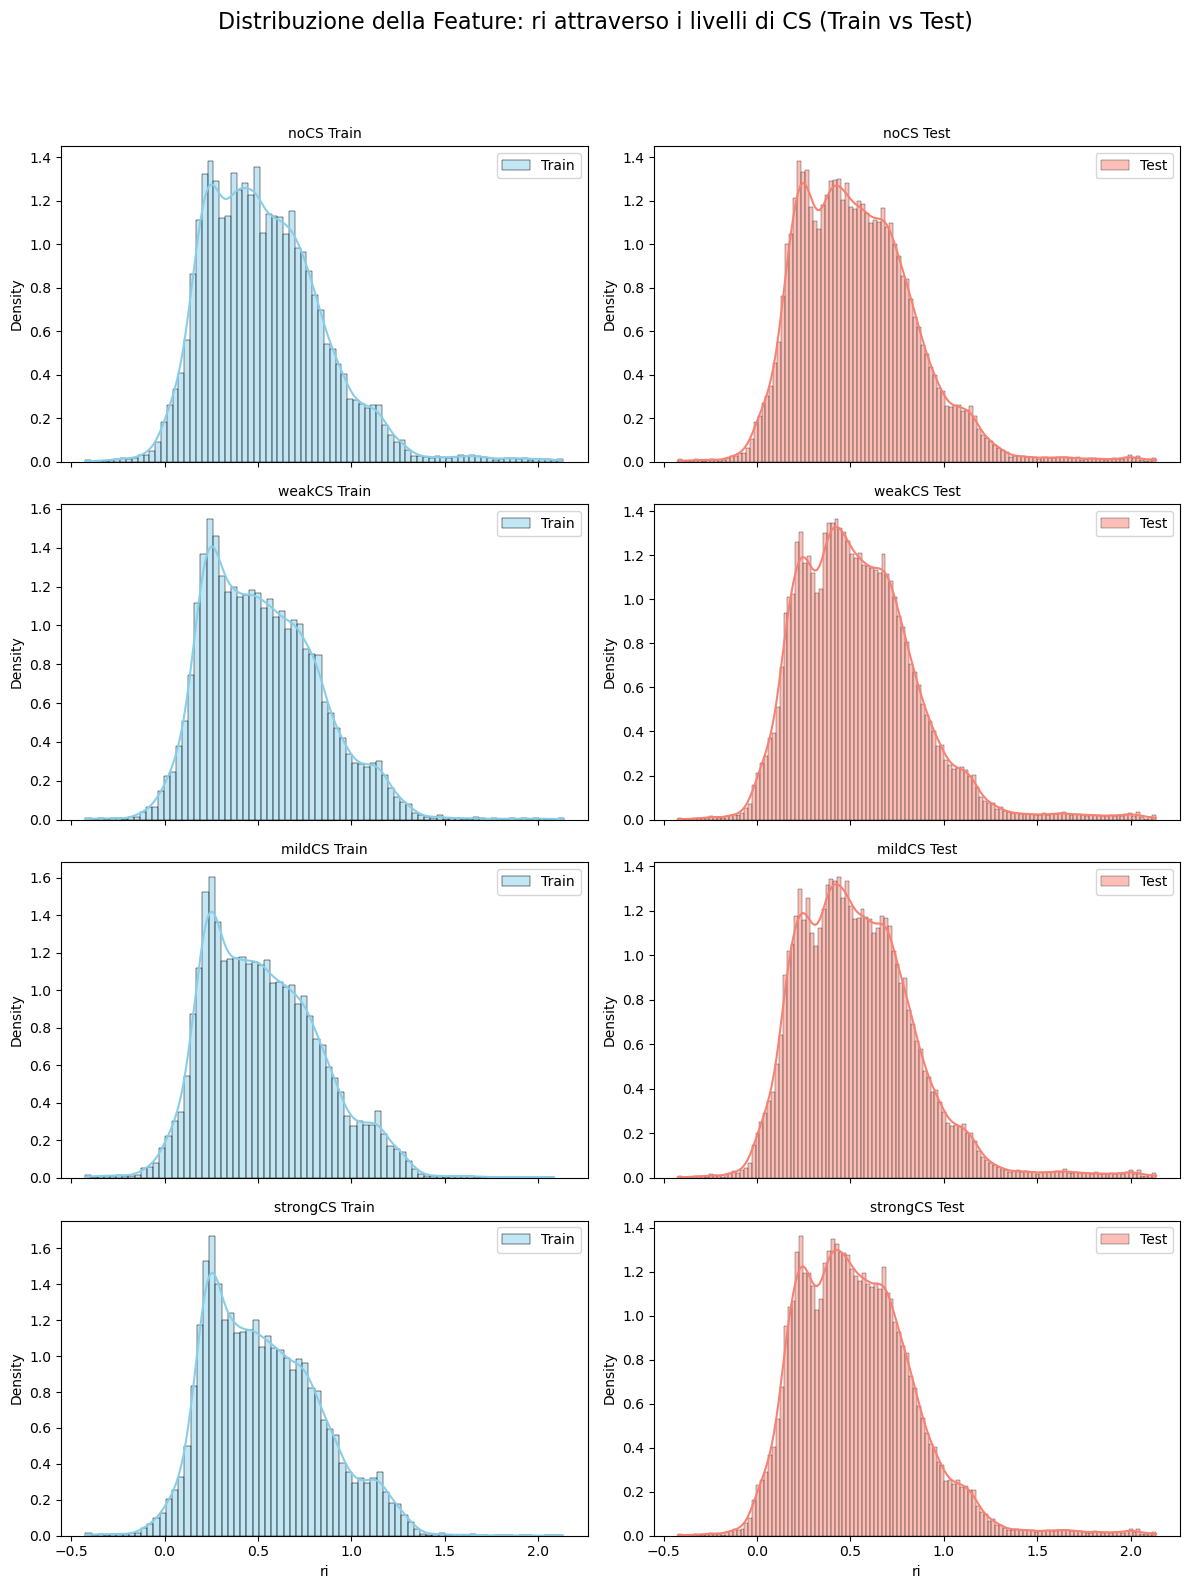

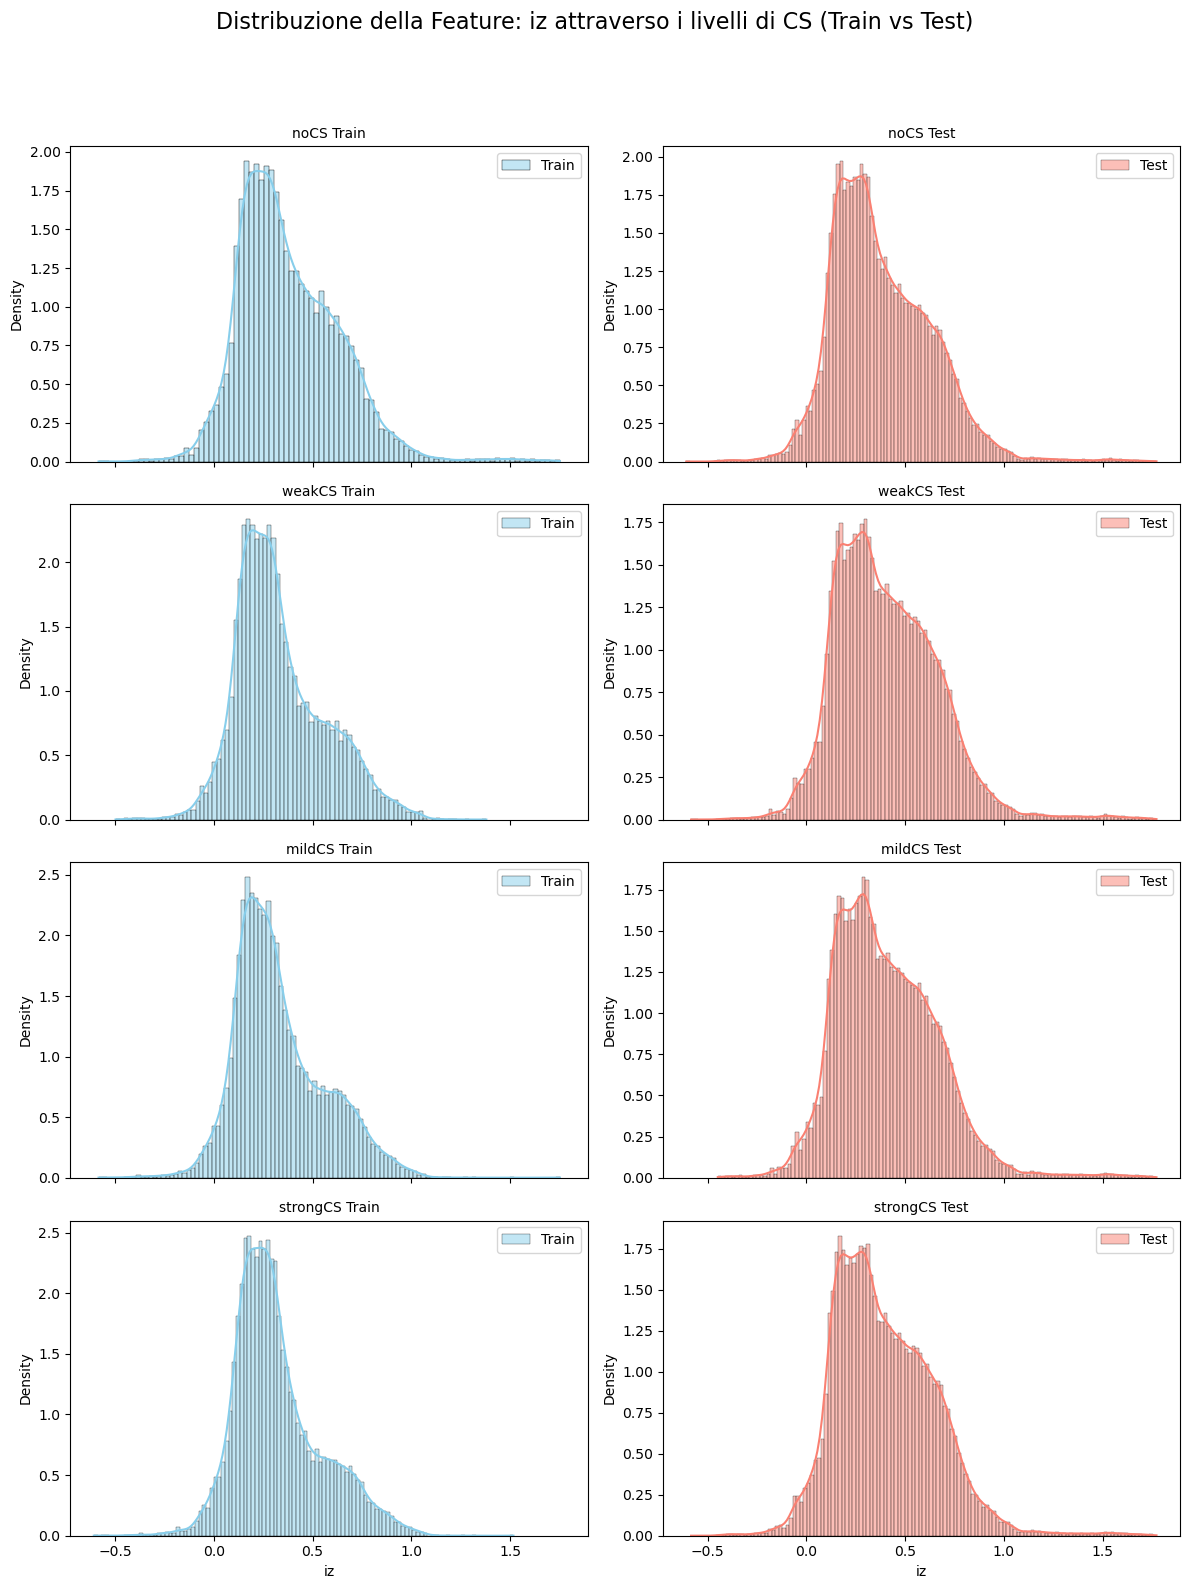

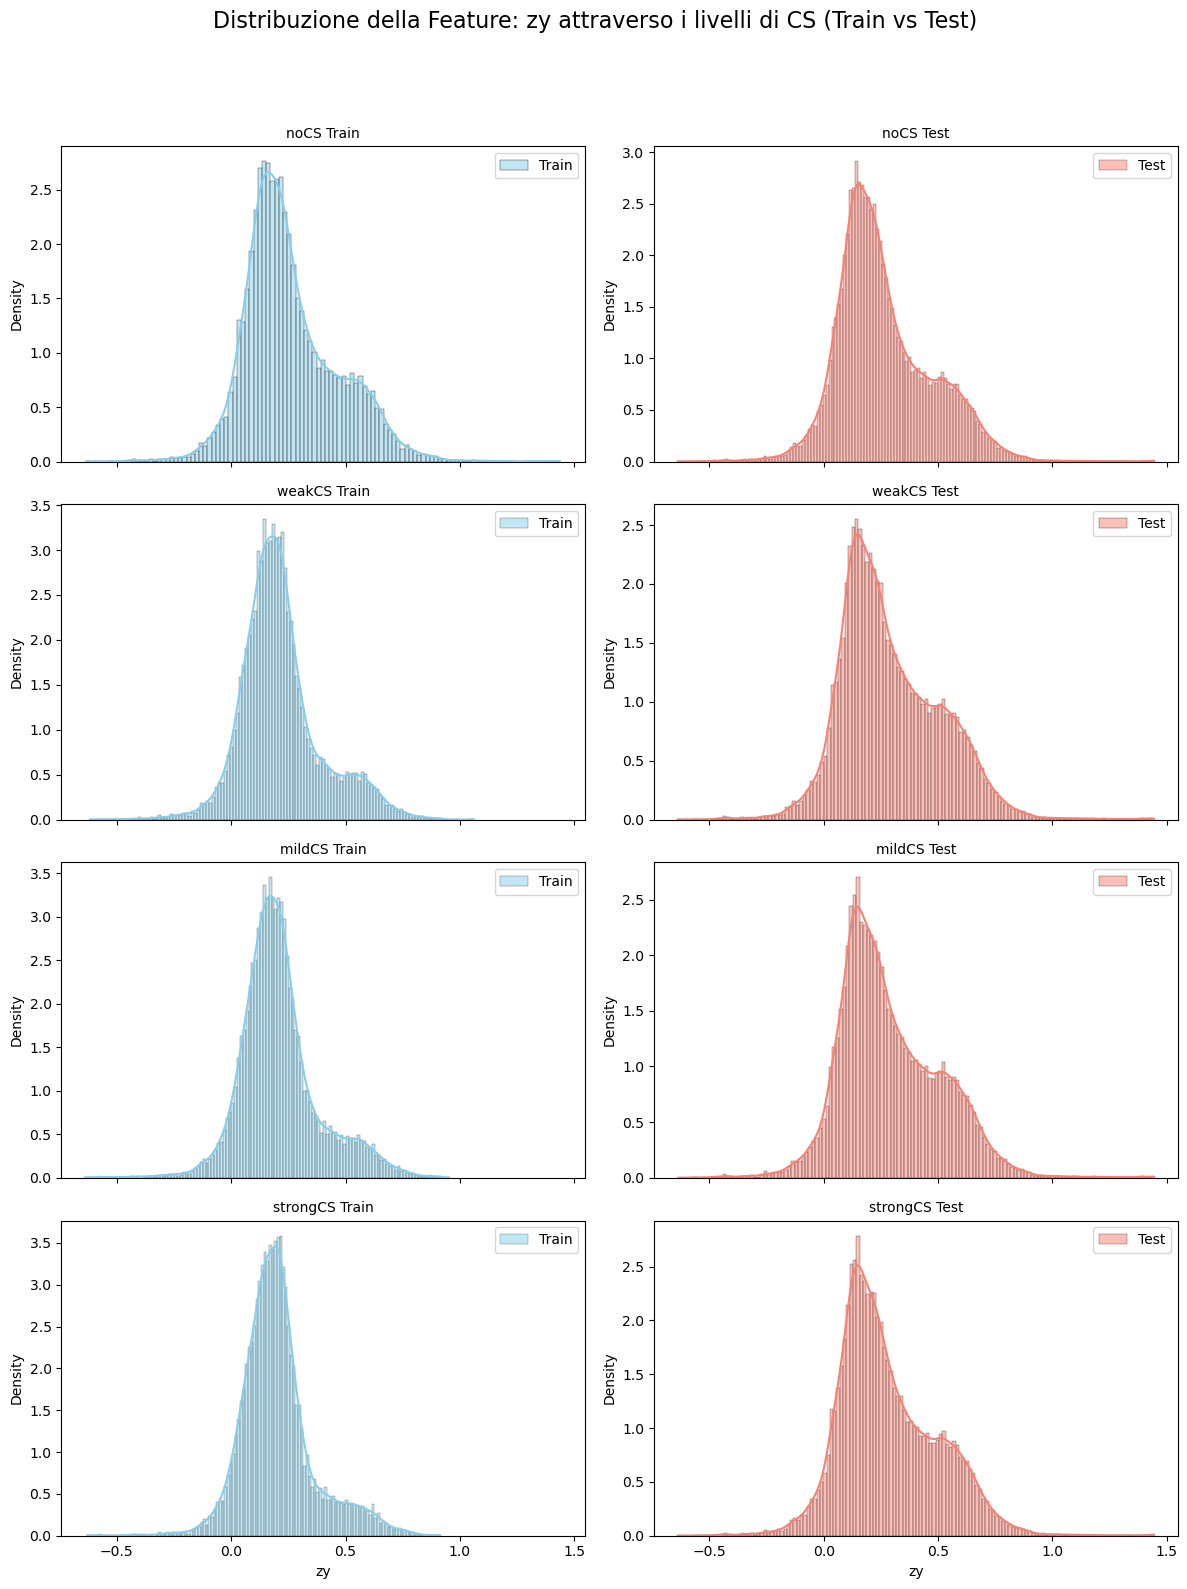

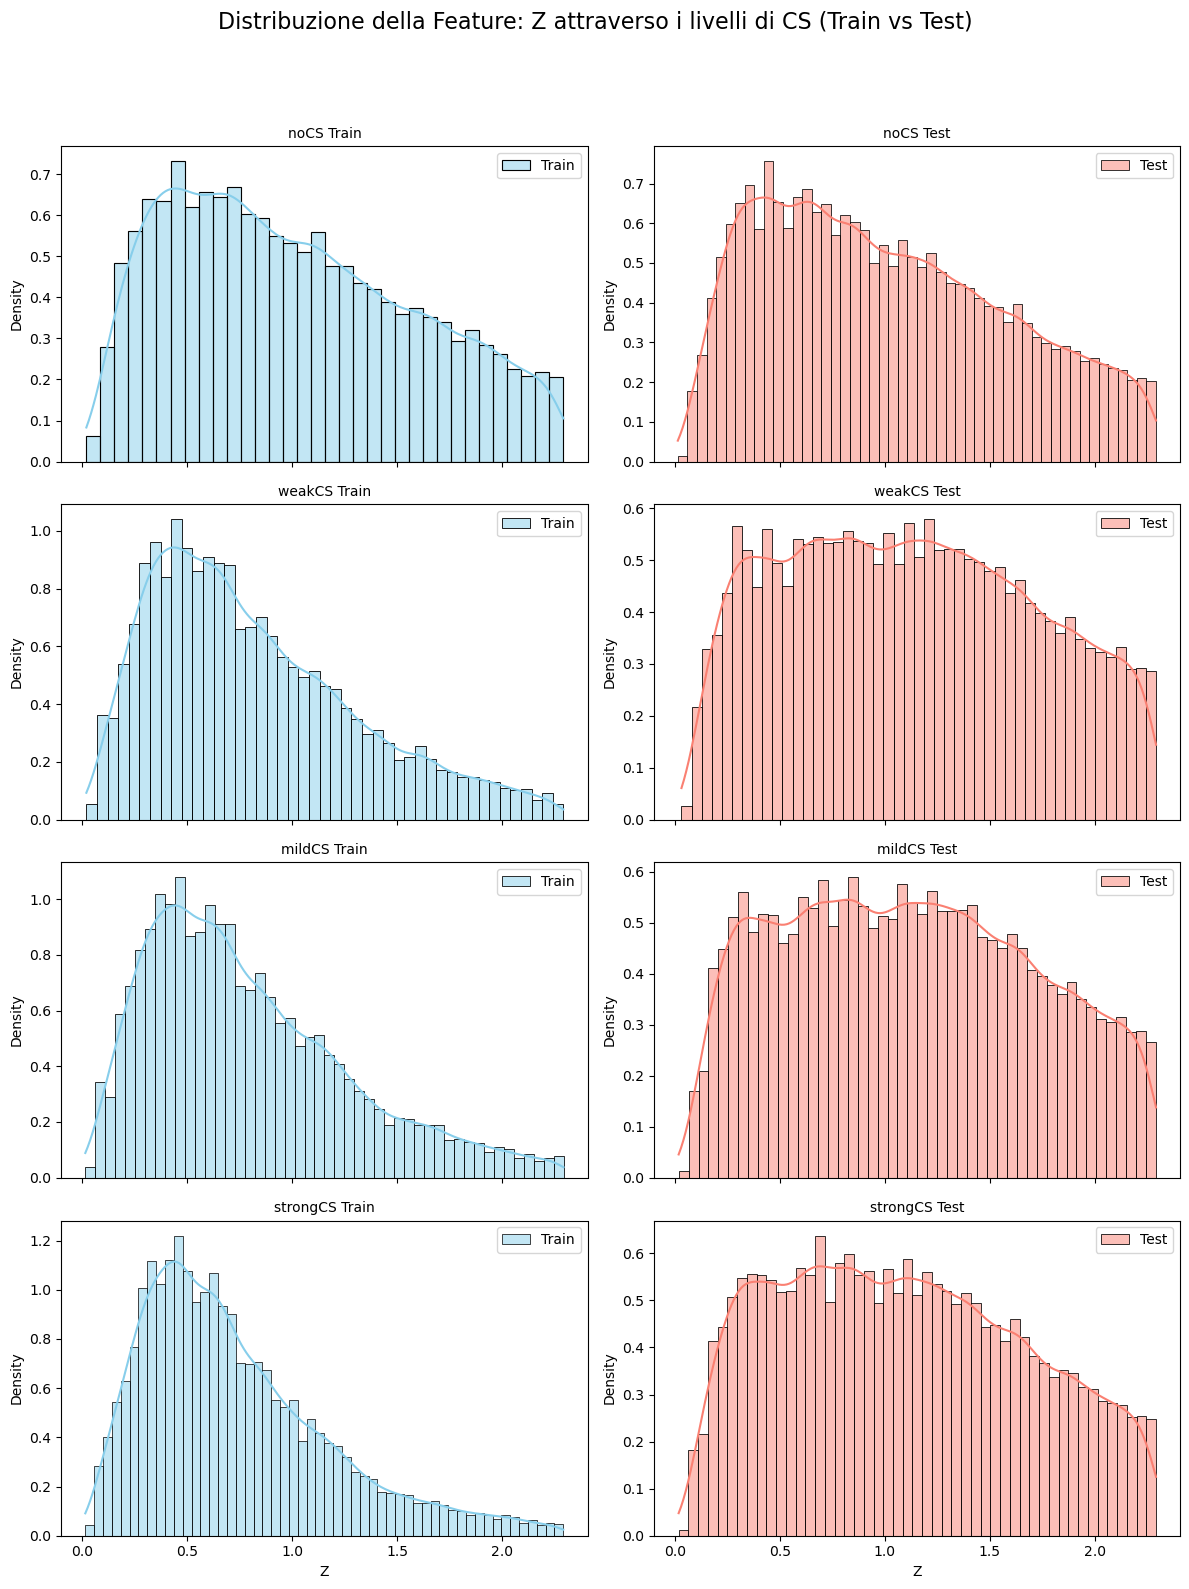

In [4]:
#Definisco le features da plottare (sapendo che sono uguali per tutti i datasets)
features = df_train_noCS.columns.tolist()

# Organizzo i dataset per livello di CS
dataset_groups = {
    'noCS': {'train': df_train_noCS, 'test': df_test_noCS},
    'weakCS': {'train': df_train_weakCS, 'test': df_test_weakCS},
    'mildCS': {'train': df_train_mildCS, 'test': df_test_mildCS},
    'strongCS': {'train': df_train_strongCS, 'test': df_test_strongCS}
}

cs_levels = ['noCS', 'weakCS', 'mildCS', 'strongCS']

# Ciclo su ogni feature e creo una figura dedicata con dei subplots
for feature in features:
    fig, axes = plt.subplots(nrows=len(cs_levels), ncols=2, figsize=(12, 4 * len(cs_levels)), sharex=True)
    fig.suptitle(f'Distribuzione della Feature: {feature} attraverso i livelli di CS (Train vs Test)', fontsize=16, y=1.02)

    for i, cs_level in enumerate(cs_levels):
        train_df = dataset_groups[cs_level]['train']
        test_df = dataset_groups[cs_level]['test']

        # Plot distribuzione di training
        sns.histplot(train_df[feature], kde=True, ax=axes[i, 0], color='skyblue', label='Train', stat='density')
        axes[i, 0].set_title(f'{cs_level} Train', fontsize=10)
        axes[i, 0].set_ylabel('Density')
        axes[i, 0].legend()

        # Plot distribuzione di test
        sns.histplot(test_df[feature], kde=True, ax=axes[i, 1], color='salmon', label='Test', stat='density')
        axes[i, 1].set_title(f'{cs_level} Test', fontsize=10)
        axes[i, 1].set_ylabel('Density')
        axes[i, 1].legend()
        axes[i, 1].set_xlabel('') 

    # Imposto una label solo per i plots di riga più bassa.
    for j in range(2):
        axes[len(cs_levels)-1, j].set_xlabel(feature)

    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) 
    plt.show()

Si osserva come in effetti, le distribuzioni delle features si differenzino sempre di più, via via che aumenta il grado di CS nel dataset.Questo ammonisce sul fatto che le prestazioni dei modelli che utilizzeremo tenderanno a peggiorare nel momento in cui aumentiamo il grado di CS presente.

L'obiettivo sarà dunque quello di individuare il modello (tra quelli che prenderemo in considerazione) che mantenga le sue prestazioni più stabili possibili all'aumentare di CS.  

## Visualizzo una descrizione riassuntiva dei dataset

In [5]:
for name, df in dfs_train.items():
    print(f"Dataset: {name}")
    print(df.describe())
    print("\n")

Dataset: df_train_noCS
                  r            ug            gr            ri            iz  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean      25.477468      0.696617      0.700313      0.533159      0.379161   
std        1.444289      0.465751      0.384544      0.313753      0.250247   
min       15.490930     -0.152908     -0.299736     -0.423622     -0.583186   
25%       24.788051      0.349135      0.429594      0.293880      0.197333   
50%       25.742474      0.659939      0.672485      0.496667      0.333019   
75%       26.418062      0.895090      0.892394      0.721704      0.542200   
max       29.946396      3.807529      2.864244      2.129913      1.750595   

                 zy             Z  
count  20000.000000  20000.000000  
mean       0.261498      1.006515  
std        0.204496      0.575278  
min       -0.635340      0.018746  
25%        0.125606      0.524755  
50%        0.218647      0.922847  
75%        0.

Si nota come tutte le feature siano dello stesso ordine di grandezza, tranne la prima. Andrò allora a standardizzarla, non tanto perché sia indispensabile per i modelli che andrò a testare, ma per facilitare il confronto tra l'importanza delle features (che ad esempio per la regressione lineare, si basa sui coefficienti delle stesse). 

## Definisco alcune funzioni utili

In [6]:
def extract_yX(df):
    y = df['Z']
    X = df.drop(['Z'], axis=1)
    return y , X 

def standardize_data(X_tr, X_te):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_te = scaler.transform(X_te)
    return X_tr, X_te

def assess_overfitting(model):
    kf = KFold(n_splits=5, shuffle=True)
    scores = cross_validate(reg, X_tr, y_tr, cv=kf, scoring="neg_mean_squared_error", return_train_score=True)
    return {-scores['train_score'].mean()}, {-scores['test_score'].mean()}

def calculate_errors(y_pred, y_te):
    mse = mean_squared_error(y_pred,y_te)
    rmse = root_mean_squared_error(y_pred,y_te)
    return mse, rmse
    

## Plot del valori di training di ciascuna feature in relazione al valore del target. Cerco pattern evidenti visualmente.

Dataset: df_train_noCS


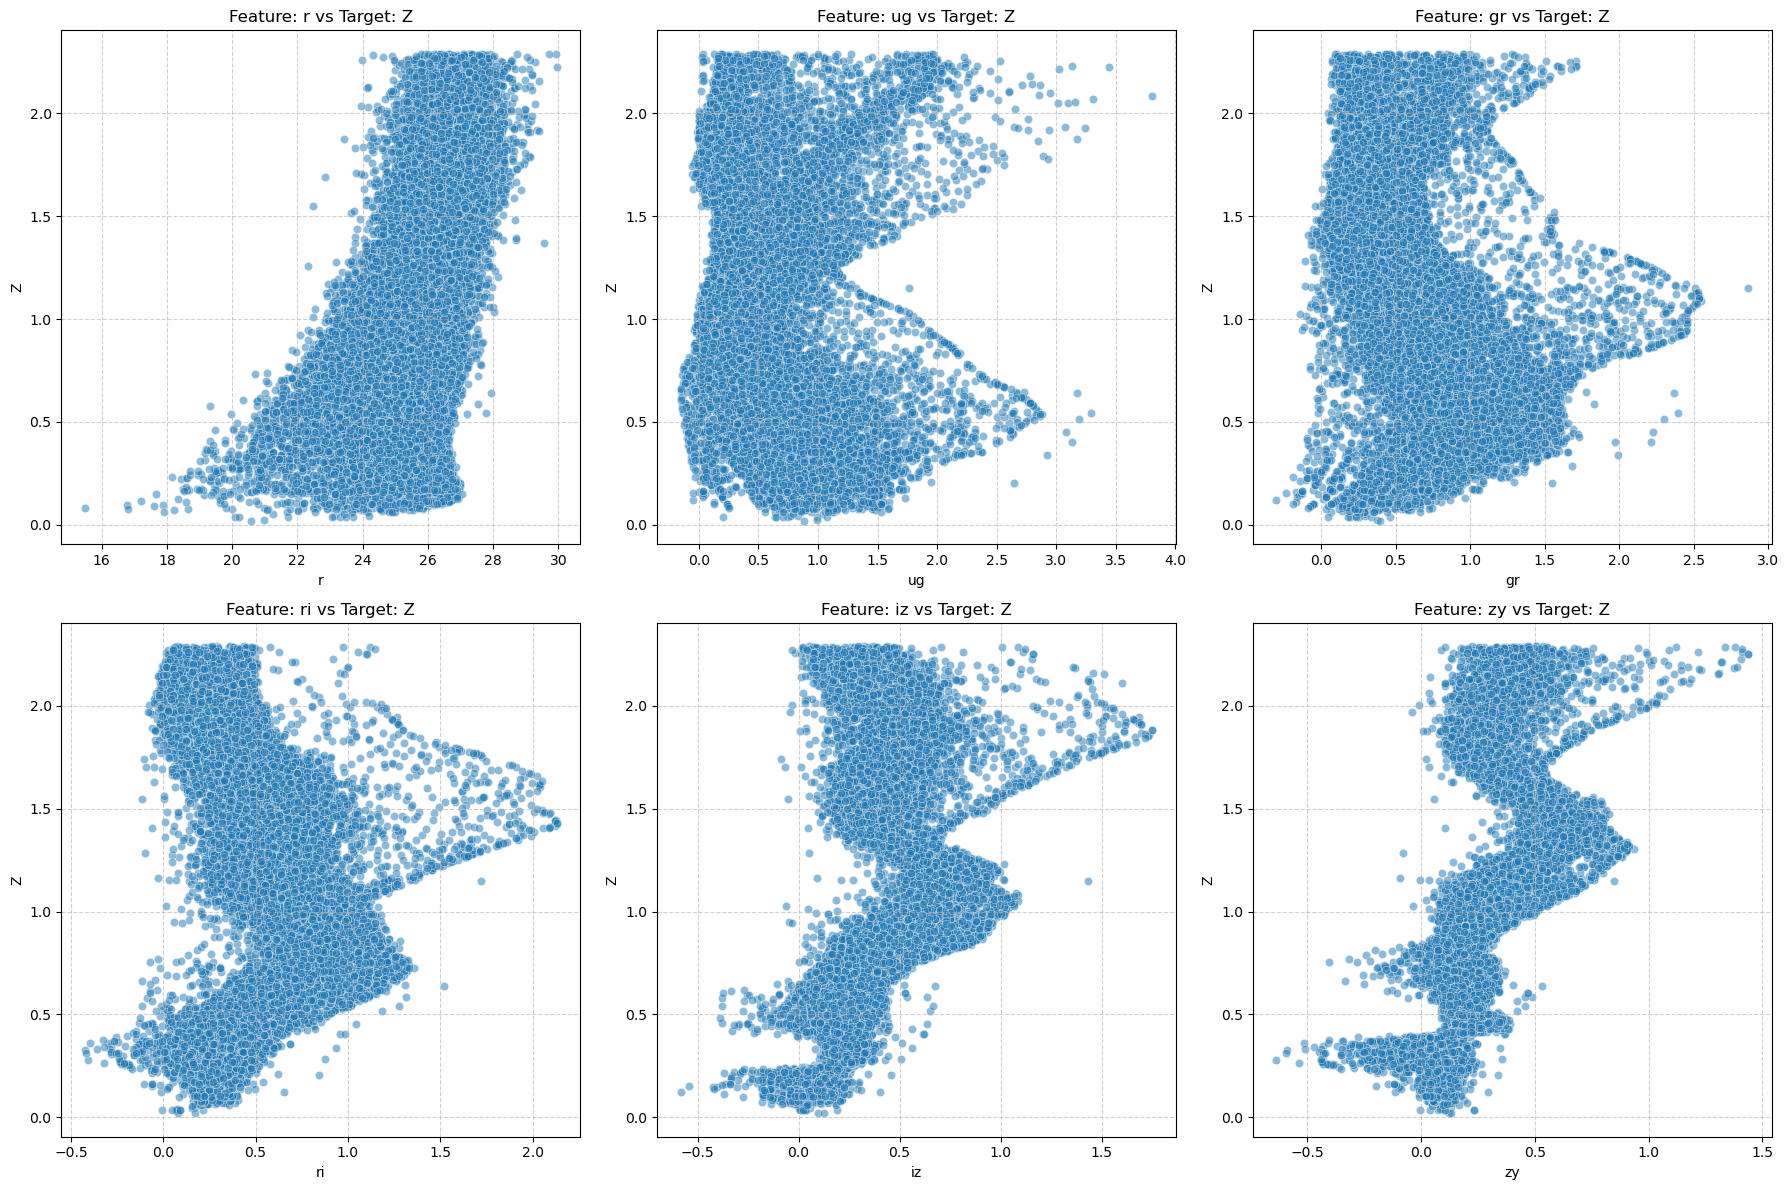

Dataset: df_train_weakCS


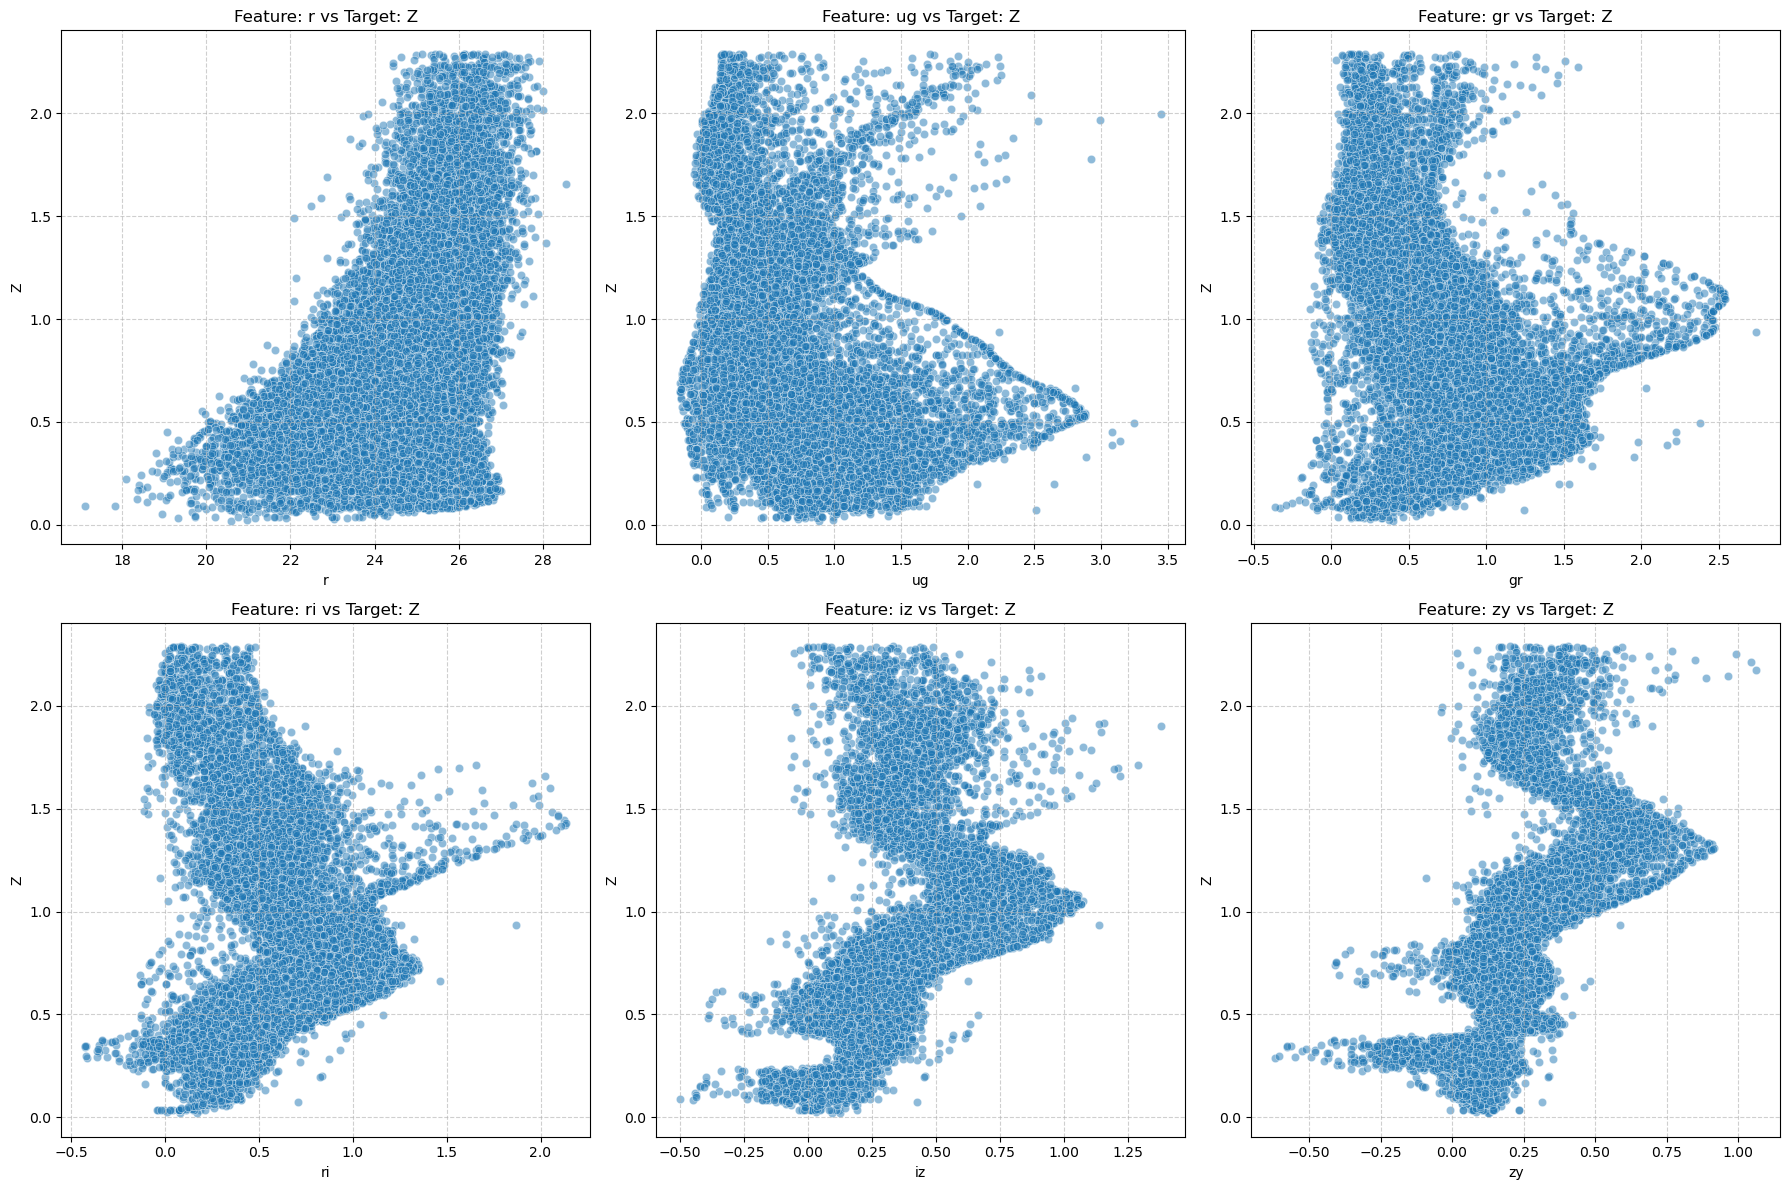

Dataset: df_train_mildCS


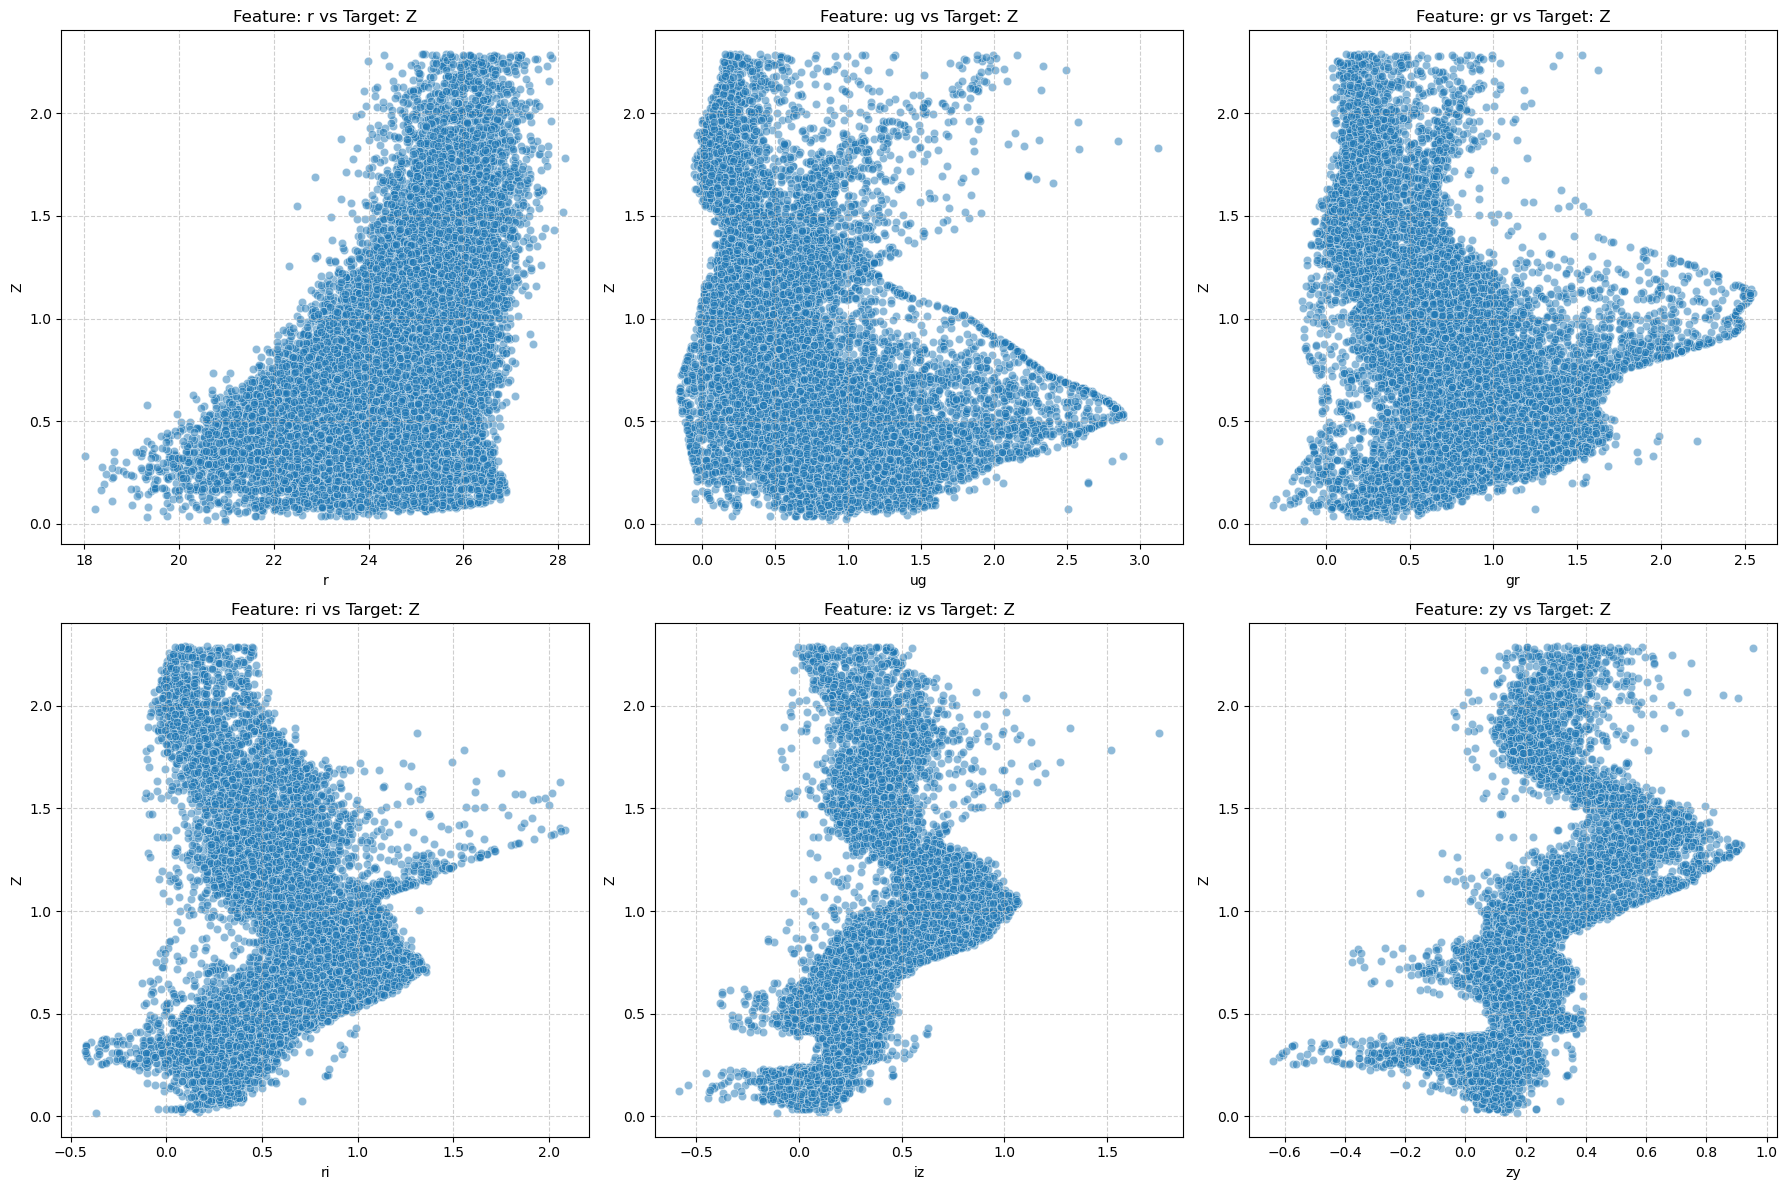

Dataset: df_train_strongCS


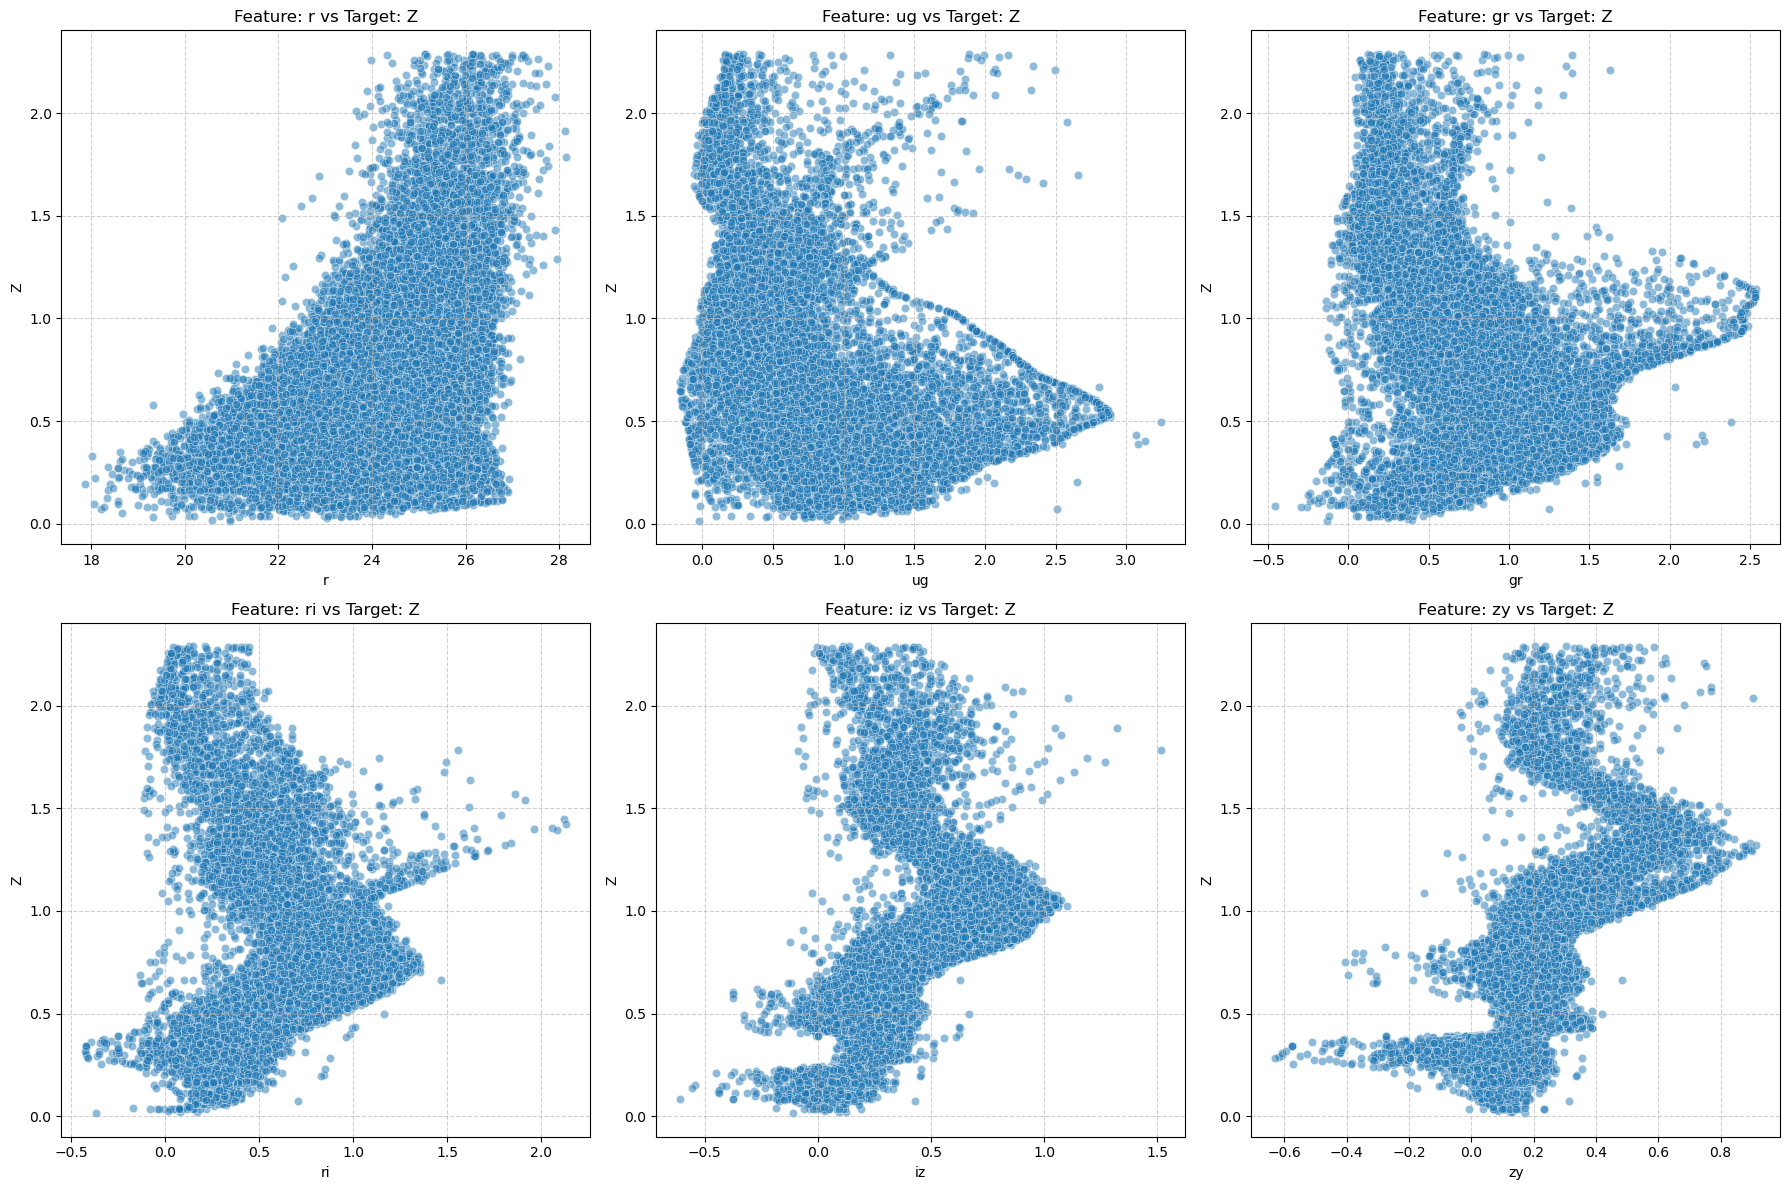

In [7]:
for name, df in dfs_train.items():
    print(f"Dataset: {name}")
    
    #Ottengo la lista delle features 
    y_tr, X_tr = extract_yX(df)
    feature_names = X_tr.columns

    #Creo figure per contenere tutti i plot
    plt.figure(figsize=(18, 12)) # Aggiusto la dimensione della figure size 

    #Loop attraverso ogni feature e creo uno scatter plot rispetto y_tr
    for i, feature in enumerate(feature_names):
        plt.subplot(2, 3, i + 1) # Predispongo i plots in una griglia 2x3
        sns.scatterplot(x=X_tr[feature], y=y_tr, alpha=0.5)
        plt.title(f'Feature: {feature} vs Target: Z')
        plt.xlabel(feature)
        plt.ylabel('Z')
        plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout() 
    plt.show()

# Dataframes in cui conservare i risultati (MSE e RMSE)

In [8]:
results_mse = pd.DataFrame(columns=['Modello','test_noCS','test_weakCS','test_mildCS','test_strongCS'])
results_rmse = pd.DataFrame(columns=['Modello','test_noCS','test_weakCS','test_mildCS','test_strongCS'])

# Baseline banale per confrontare i modelli

In [9]:
row_mse_results = ["Baseline"]
row_rmse_results = ["Baseline"]
for name, group in dataset_groups.items():
    y_tr, X_tr = extract_yX(group["train"])
    y_te, X_te = extract_yX(group['test'])
    
    y_mean = y_tr.mean()
    y_pred_baseline = y_mean * np.ones(y_te.shape)
    
    baseline_mse = mean_squared_error(y_pred_baseline, y_te)
    baseline_rmse = root_mean_squared_error(y_pred_baseline, y_te)
    row_mse_results.append(baseline_mse)
    row_rmse_results.append(baseline_rmse)

results_mse.loc[len(results_mse)] = row_mse_results
results_rmse.loc[len(results_rmse)] = row_rmse_results

display(results_mse)
display(results_rmse)

,Modello,test_noCS,test_weakCS,test_mildCS,test_strongCS
0,Baseline,0.329365,0.438801,0.451955,0.464708


,Modello,test_noCS,test_weakCS,test_mildCS,test_strongCS
0,Baseline,0.573903,0.662421,0.672276,0.681695


Devo analizzare 4 datasets.
Devo fare train baseline su trin set e poi valutazione su test set collegato
Ottengo così il primo valore della riga nuova degli scores.

Devo poi fare train baseline su altro train set e poi valutazione su test set collegato
Ottengi così il secondo valore della reiga nuova degli scores.

# Regressione Lineare

Definisco un modello di regressione lineare, e vado poi a fare cross validation per valutare la presenza di overfitting o meno.

In [12]:
row_mse_results = ["Regressione Lineare"]
row_rmse_results = ["Regressione Lineare"]

#Serve poi per explainability
coefficients_importance = []

for name, group in dataset_groups.items():
    y_tr, X_tr = extract_yX(group["train"])
    y_te, X_te = extract_yX(group['test'])

    X_tr, X_te = standardize_data(X_tr, X_te)
    
    kf = KFold(n_splits=5, shuffle=True)
    reg = LinearRegression()
    scores = cross_validate(reg, X_tr, y_tr, cv=kf, scoring="neg_mean_squared_error", return_train_score=True)

    #Studio dell'overfitting usando cross validation. DECIDERE DOVE METTERLO PER EVITARE QUESTI PRINT
    print(f"Train MSE: {-scores['train_score'].mean():.4f}")
    print(f"Val MSE:   {-scores['test_score'].mean():.4f}")

    reg.fit(X_tr, y_tr)

    #Serve poi per explainability
    coefficients_importance.append(reg.coef_)
    
    y_pred = reg.predict(X_te)
    mse = mean_squared_error(y_te, y_pred)
    rmse = root_mean_squared_error(y_te, y_pred)
    row_mse_results.append(mse)
    row_rmse_results.append(rmse)

    

results_mse.loc[len(results_mse)] = row_mse_results
results_rmse.loc[len(results_rmse)] = row_rmse_results

display(results_mse)
display(results_rmse)

Train MSE: 0.1193
Val MSE:   0.1194
Train MSE: 0.0840
Val MSE:   0.0840
Train MSE: 0.0802
Val MSE:   0.0803
Train MSE: 0.0684
Val MSE:   0.0685


,Modello,test_noCS,test_weakCS,test_mildCS,test_strongCS
0,Baseline,0.329365,0.438801,0.451955,0.464708
1,Regressione Lineare,0.118941,0.150276,0.153320,0.151714
2,Regressione Lineare,0.118941,0.150276,0.153320,0.151714


,Modello,test_noCS,test_weakCS,test_mildCS,test_strongCS
0,Baseline,0.573903,0.662421,0.672276,0.681695
1,Regressione Lineare,0.344879,0.387655,0.391561,0.389504
2,Regressione Lineare,0.344879,0.387655,0.391561,0.389504


## Explainability usando Regressione Lineare

Ora valutiamo l'importanza delle features date dalla regressione lineare. Per farlo considero i coefficienti imparati dal modello. I coefficienti in valore assoluto più grandi sono quelli di maggior importanza.

In [13]:
cs_levels = ['noCS', 'weakCS', 'mildCS', 'strongCS']

for i in range(len(cs_levels)):
    #Voglio creare un dataframe in cui stanno sia i nomi delle features,
    #sia i coefficienti delle stesse
    df_without_target = df_train_noCS.drop(['Z'], axis=1)
    df_importance = pd.DataFrame({'Feature':df_without_target.columns, 'Importance':coefficients_importance[i]})
    df_coef_abs = df_importance['Importance'].abs()
    df_importance['Importance_abs']=df_coef_abs
    df_importance = df_importance.sort_values(by='Importance_abs', ascending=False)
    display(df_importance)



,Feature,Importance,Importance_abs
5,zy,0.251859,0.251859
4,iz,0.202397,0.202397
2,gr,-0.192447,0.192447
0,r,0.113586,0.113586
3,ri,-0.071009,0.071009
1,ug,0.026390,0.026390


,Feature,Importance,Importance_abs
5,zy,0.211286,0.211286
2,gr,-0.178847,0.178847
4,iz,0.168190,0.168190
0,r,0.095952,0.095952
1,ug,-0.015123,0.015123
3,ri,0.002007,0.002007


,Feature,Importance,Importance_abs
5,zy,0.204914,0.204914
2,gr,-0.171726,0.171726
4,iz,0.162354,0.162354
0,r,0.091793,0.091793
1,ug,-0.025759,0.025759
3,ri,0.012986,0.012986


,Feature,Importance,Importance_abs
5,zy,0.184119,0.184119
2,gr,-0.161140,0.161140
4,iz,0.155470,0.155470
0,r,0.090481,0.090481
1,ug,-0.031097,0.031097
3,ri,0.027694,0.027694


Si nota come variando il grado di CS del dataset, cambi anche l'ordine di importanza delle features valutato tramite i coefficienti di regressione.

La feature più importante è sempre la `zy`, ma le altre variano quasi tutte la propria importanza relativa alla decisione finale del modello.